# Kalp Hastalığı Veri Seti: Veri Ön İşleme ve Veri Kalitesi Analizi

Bu notebook, dört kişilik akademik veri madenciliği projesindeki kişisel katkım olan **veri ön işleme ve veri kalitesi** adımlarını yeniden üretilebilir biçimde sunar.

## Amaç

- Ham veri setinin yapısını ve veri kalitesini incelemek
- Tekrarlanan kayıtları temizlemek
- Alan kurallarına uymayan kodları eksik değer olarak ele almak
- Temizlenmiş, ancak henüz ölçeklenmemiş veri setini üretmek
- Modelleme öncesinde veri sızıntısını önleyen bir eğitim/test hazırlığı göstermek

> Bu çalışma eğitim amaçlıdır; klinik tanı veya tıbbi karar desteği amacıyla kullanılmamalıdır.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_PATH = Path("heart.csv")
CLEAN_DATA_PATH = Path("heart_cleaned.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "heart.csv bulunamadı. Notebook ile aynı klasörde bulunduğundan emin olun."
    )


## 1. Verinin yüklenmesi ve şema kontrolü

Beklenen veri seti 14 sütundan oluşur. Kod, eksik veya beklenmeyen sütunları çalışmanın başında kontrol eder.


In [2]:
expected_columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df_raw = pd.read_csv(DATA_PATH)

missing_columns = sorted(set(expected_columns) - set(df_raw.columns))
unexpected_columns = sorted(set(df_raw.columns) - set(expected_columns))

if missing_columns:
    raise ValueError(f"Eksik sütunlar: {missing_columns}")

print(f"Ham veri boyutu: {df_raw.shape[0]} satır × {df_raw.shape[1]} sütun")
print(f"Beklenmeyen sütunlar: {unexpected_columns if unexpected_columns else 'Yok'}")
display(df_raw.head())


Ham veri boyutu: 1025 satır × 14 sütun
Beklenmeyen sütunlar: Yok


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Veri kalitesi denetimi

Bu adımda tekrar eden kayıtlar, eksik değerler, sıfır değerleri ve kategorik alanların beklenen aralıkları incelenir.

Önemli metodolojik düzeltme: `chol` ve `trestbps` alanlarında sıfır bulunup bulunmadığı doğrudan veriden kontrol edilir; örnek göstermek amacıyla veriye yapay sıfır eklenmez.


In [3]:
duplicate_count = int(df_raw.duplicated().sum())
missing_count = int(df_raw.isna().sum().sum())

quality_summary = pd.DataFrame({
    "Kontrol": [
        "Toplam satır",
        "Tekrarlanan satır",
        "Benzersiz satır",
        "Toplam eksik değer",
        "chol = 0",
        "trestbps = 0",
        "ca = 4 (beklenen 0-3 dışında)",
        "thal = 0 (eksik/bilinmeyen kod)"
    ],
    "Değer": [
        len(df_raw),
        duplicate_count,
        len(df_raw) - duplicate_count,
        missing_count,
        int((df_raw["chol"] == 0).sum()),
        int((df_raw["trestbps"] == 0).sum()),
        int((df_raw["ca"] == 4).sum()),
        int((df_raw["thal"] == 0).sum())
    ]
})

display(quality_summary)


,Kontrol,Değer
0,Toplam satır,1025
1,Tekrarlanan satır,723
2,Benzersiz satır,302
3,Toplam eksik değer,0
4,chol = 0,0
5,trestbps = 0,0
6,ca = 4 (beklenen 0-3 dışında),18
7,thal = 0 (eksik/bilinmeyen kod),7


## 3. Temizleme

Uygulanan işlemler:

1. Tamamen aynı olan tekrar kayıtlar kaldırılır.
2. `chol` veya `trestbps` alanında sıfır varsa eksik değer kabul edilip medyanla doldurulur.
3. Veri sözlüğünde `ca` için beklenen aralık 0–3 olduğundan `ca = 4`; `thal` için `0` kodu ise eksik/bilinmeyen değer olarak ele alınır.
4. Bu iki kategorik alandaki eksikler, temiz veri içindeki en sık değerle doldurulur.
5. Temiz veri **ölçeklenmeden ve one-hot encoding uygulanmadan** kaydedilir. Böylece sonraki modeller ön işleme dönüşümlerini yalnızca eğitim verisine fit ederek veri sızıntısını önleyebilir.


In [4]:
df_clean = df_raw.drop_duplicates().reset_index(drop=True).copy()

# Fizyolojik ölçümlerde 0 gözlenirse koşullu olarak medyanla doldur.
for column in ["chol", "trestbps"]:
    zero_mask = df_clean[column].eq(0)
    if zero_mask.any():
        df_clean.loc[zero_mask, column] = np.nan
        df_clean[column] = df_clean[column].fillna(df_clean[column].median())

# Veri sözlüğüne göre aralık dışı / eksik kodları düzenle.
df_clean["ca"] = df_clean["ca"].replace(4, np.nan)
df_clean["thal"] = df_clean["thal"].replace(0, np.nan)

for column in ["ca", "thal"]:
    mode_value = df_clean[column].mode(dropna=True)
    if mode_value.empty:
        raise ValueError(f"{column} sütunu için doldurma değeri üretilemedi.")
    df_clean[column] = df_clean[column].fillna(mode_value.iloc[0]).astype(int)

# Temel bütünlük kontrolleri
assert df_clean.duplicated().sum() == 0
assert df_clean.isna().sum().sum() == 0
assert set(df_clean["target"].unique()) <= {0, 1}
assert df_clean["ca"].between(0, 3).all()
assert df_clean["thal"].isin([1, 2, 3]).all()

df_clean.to_csv(CLEAN_DATA_PATH, index=False)

print(f"Temiz veri boyutu: {df_clean.shape[0]} satır × {df_clean.shape[1]} sütun")
print(f"Kaydedilen dosya: {CLEAN_DATA_PATH.resolve()}")
display(df_clean.head())


Temiz veri boyutu: 302 satır × 14 sütun
Kaydedilen dosya: /mnt/data/heart_fixed_test/heart_cleaned.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 4. Keşifsel veri analizi

Sınıf dağılımı ve sayısal değişkenler arasındaki korelasyonlar, modelleme öncesinde veri yapısını anlamak için incelenir.


,Kayıt sayısı,Oran
Sağlıklı (0),138,0.457
Kalp hastalığı (1),164,0.543


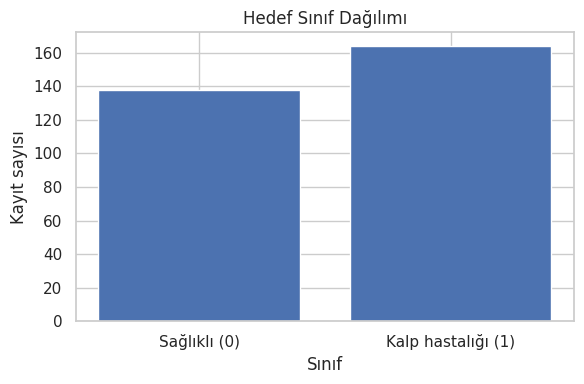

In [5]:
class_counts = df_clean["target"].value_counts().sort_index()
class_ratios = df_clean["target"].value_counts(normalize=True).sort_index()

distribution_table = pd.DataFrame({
    "Kayıt sayısı": class_counts,
    "Oran": class_ratios.round(3)
})
distribution_table.index = ["Sağlıklı (0)", "Kalp hastalığı (1)"]
display(distribution_table)

plt.figure(figsize=(6, 4))
plt.bar(["Sağlıklı (0)", "Kalp hastalığı (1)"], class_counts.values)
plt.title("Hedef Sınıf Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Kayıt sayısı")
plt.tight_layout()
plt.show()


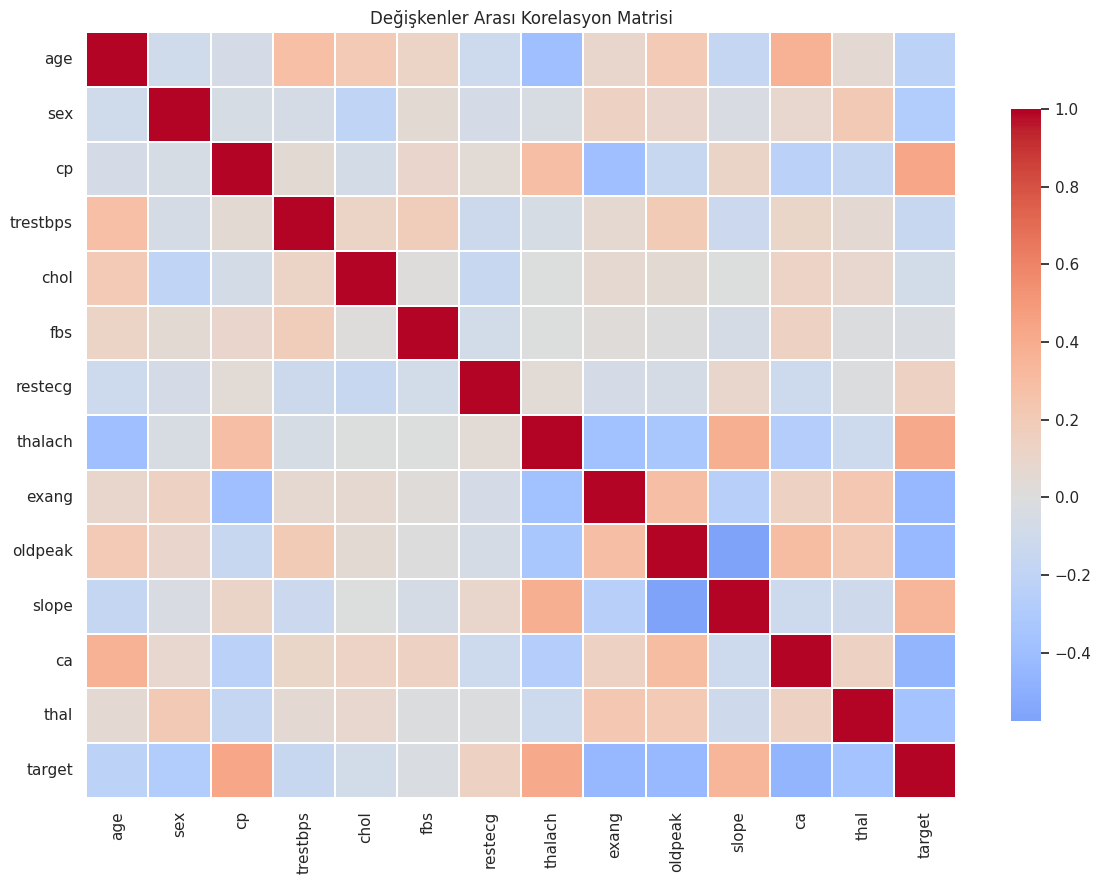

,target ile korelasyon
ca,-0.463886
exang,-0.435601
cp,0.432080
oldpeak,-0.429146
thalach,0.419955
thal,-0.362313
slope,0.343940
sex,-0.283609
age,-0.221476
trestbps,-0.146269


In [6]:
plt.figure(figsize=(12, 9))
correlation_matrix = df_clean.corr(numeric_only=True)
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8}
)
plt.title("Değişkenler Arası Korelasyon Matrisi")
plt.tight_layout()
plt.show()

target_correlations = (
    correlation_matrix["target"]
    .drop("target")
    .sort_values(key=lambda series: series.abs(), ascending=False)
    .to_frame("target ile korelasyon")
)
display(target_correlations.head(10))


## 5. Veri sızıntısını önleyen modelleme hazırlığı

Ölçekleyici ve one-hot encoder, veri bölünmeden önce tüm veri üzerinde fit edilmemelidir. Aşağıdaki örnekte:

- Eğitim/test ayrımı `stratify=y` ile yapılır.
- Dönüşümler yalnızca `X_train` üzerinde öğrenilir.
- Aynı dönüşümler daha sonra `X_test` üzerine uygulanır.

Bu notebook model geliştirme iddiasında bulunmaz; yalnızca ekipteki modellerin güvenli biçimde kullanabileceği ön işleme yaklaşımını gösterir.


In [7]:
X = df_clean.drop(columns="target")
y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_columns = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_columns),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print(f"Eğitim kümesi: {X_train.shape} → {X_train_processed.shape}")
print(f"Test kümesi:    {X_test.shape} → {X_test_processed.shape}")
print(f"Eğitim hedef dağılımı:\n{y_train.value_counts(normalize=True).sort_index().round(3)}")
print(f"Test hedef dağılımı:\n{y_test.value_counts(normalize=True).sort_index().round(3)}")
print("\nÜretilen ilk 12 özellik:")
print(feature_names[:12].tolist())


Eğitim kümesi: (241, 13) → (241, 20)
Test kümesi:    (61, 13) → (61, 20)
Eğitim hedef dağılımı:
target
0    0.456
1    0.544
Name: proportion, dtype: float64
Test hedef dağılımı:
target
0    0.459
1    0.541
Name: proportion, dtype: float64

Üretilen ilk 12 özellik:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex_1', 'cp_1', 'cp_2', 'cp_3', 'fbs_1', 'restecg_1', 'restecg_2']


## 6. Sonuç

- 1.025 kayıttan 723 tekrar kaldırılmış ve 302 benzersiz kayıt elde edilmiştir.
- Mevcut ham dosyada `chol` ve `trestbps` için sıfır değer bulunmamıştır; kod bu durumu yine de koşullu olarak kontrol eder.
- `ca = 4` ve `thal = 0` kodları eksik/bilinmeyen değer olarak düzenlenmiştir.
- Temiz veri `heart_cleaned.csv` olarak, ölçekleme uygulanmadan kaydedilmiştir.
- Ölçekleme ve encoding işlemlerinin yalnızca eğitim verisine fit edilmesiyle veri sızıntısı riski azaltılmıştır.

Bu yaklaşım, farklı modellerin aynı temiz veri üzerinde karşılaştırılmasını sağlarken model değerlendirmesinin metodolojik bütünlüğünü korur.
